# PUNCH L3 coronagraph FITS viewer

Quick viewer for PUNCH white-light Level-3 images (e.g. `PUNCH_L3_CAM_*.fits`).

**Setup:** select the project `.venv` kernel, then run all cells.

The science image is in **HDU 1** (4096×4096). The Sun is at the image center (pixel 2048, 2048).

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.visualization import AsinhStretch, ImageNormalize, LogStretch

%matplotlib inline

REPO_ROOT = Path.cwd()
FITS_PATH = REPO_ROOT / "PUNCH_L3_CAM_20260219001600_v0j.fits"

if not FITS_PATH.exists():
    raise FileNotFoundError(f"FITS file not found: {FITS_PATH}")

print(f"File: {FITS_PATH.name}")
print(f"Size: {FITS_PATH.stat().st_size / 1e6:.1f} MB")

File: PUNCH_L3_CAM_20260219001600_v0j.fits
Size: 22.6 MB


In [13]:
with fits.open(FITS_PATH) as hdul:
    hdul.info()
    data = hdul[1].data.copy()
    header = hdul[1].header

print()
print(f"Data shape: {data.shape}  dtype: {data.dtype}")
print(f"DATE-OBS:   {header['DATE-OBS']}")
print(f"Telescope:  {header['TELESCOP']}")
print(f"Instrument: {header['INSTRUME']}")
print(f"Object:     {header['OBJECT']}")
print(f"WCS:        {header['CTYPE1']}, {header['CTYPE2']}")
print(f"Pixel scale: {header['CDELT1']} deg/pixel")
print(f"Sun center:  ({header['CRPIX1']}, {header['CRPIX2']})")
print(f"Value range: {np.nanmin(data):.3e} … {np.nanmax(data):.3e}")
print(f"Percentiles 1/50/99: {np.nanpercentile(data, [1, 50, 99])}")

Filename: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/PUNCH_L3_CAM_20260219001600_v0j.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  PRIMARY DATA ARRAY    1 CompImageHDU    141   (4096, 4096)   float32   
  2  UNCERTAINTY ARRAY    1 CompImageHDU    141   (4096, 4096)   float64   
  3  FILE PROVENANCE    1 BinTableHDU     13   4R x 1C   [40A]   

Data shape: (4096, 4096)  dtype: float32
DATE-OBS:   2026-02-19T00:16:00.000
Telescope:  PUNCH 1-2-3-4
Instrument: WFI+NFI Mosaic
Object:     Heliosphere white light
WCS:        HPLN-ARC, HPLT-ARC
Pixel scale: 0.0225 deg/pixel
Sun center:  (2048.0, 2048.0)
Value range: -2.028e-12 … 4.472e-11
Percentiles 1/50/99: [0.00000000e+00 1.83073053e-13 3.78862944e-12]


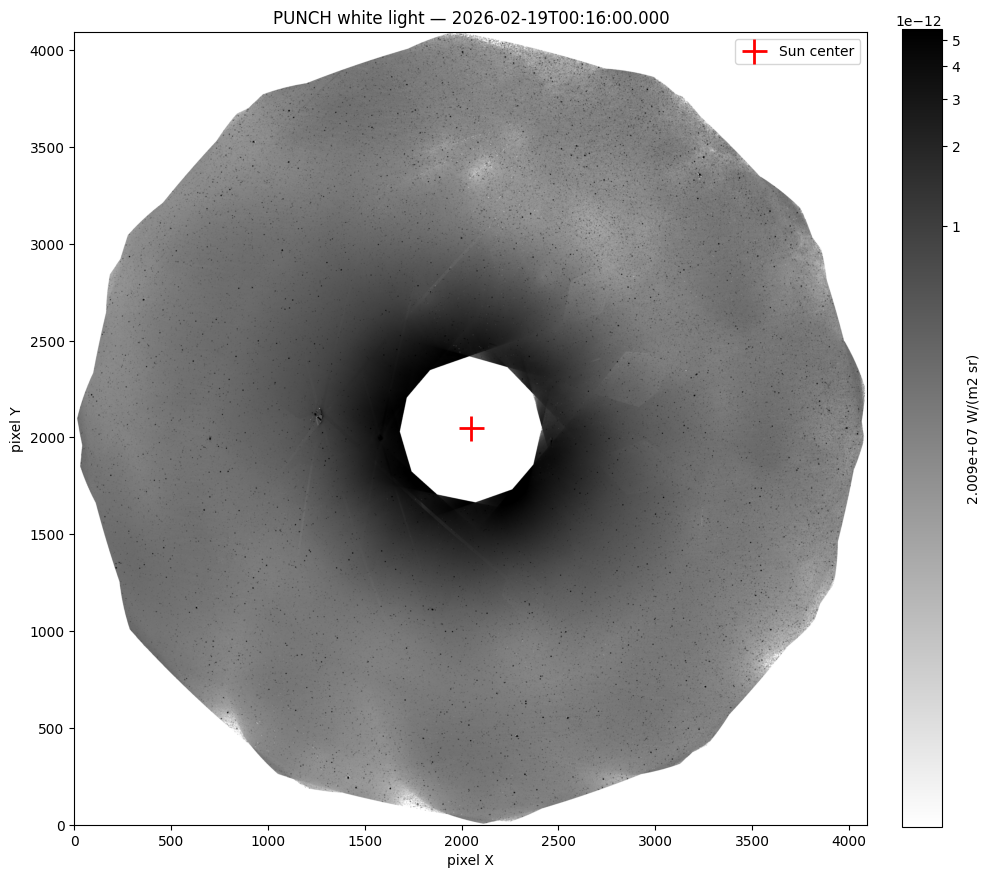

In [14]:
# Log stretch — good default for coronagraph white light
sun_x = float(header["CRPIX1"]) - 1  # matplotlib 0-based
sun_y = float(header["CRPIX2"]) - 1

vmax = np.nanpercentile(data, 99.9)
norm = ImageNormalize(data, stretch=LogStretch(), vmin=1e-15, vmax=vmax)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(data, origin="lower", cmap="gray_r", norm=norm)
ax.plot(sun_x, sun_y, "r+", markersize=18, markeredgewidth=2, label="Sun center")
ax.set_title(f"PUNCH white light — {header['DATE-OBS']}")
ax.set_xlabel("pixel X")
ax.set_ylabel("pixel Y")
ax.legend(loc="upper right")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=header.get("BUNIT", "counts"))
plt.tight_layout()
plt.show()

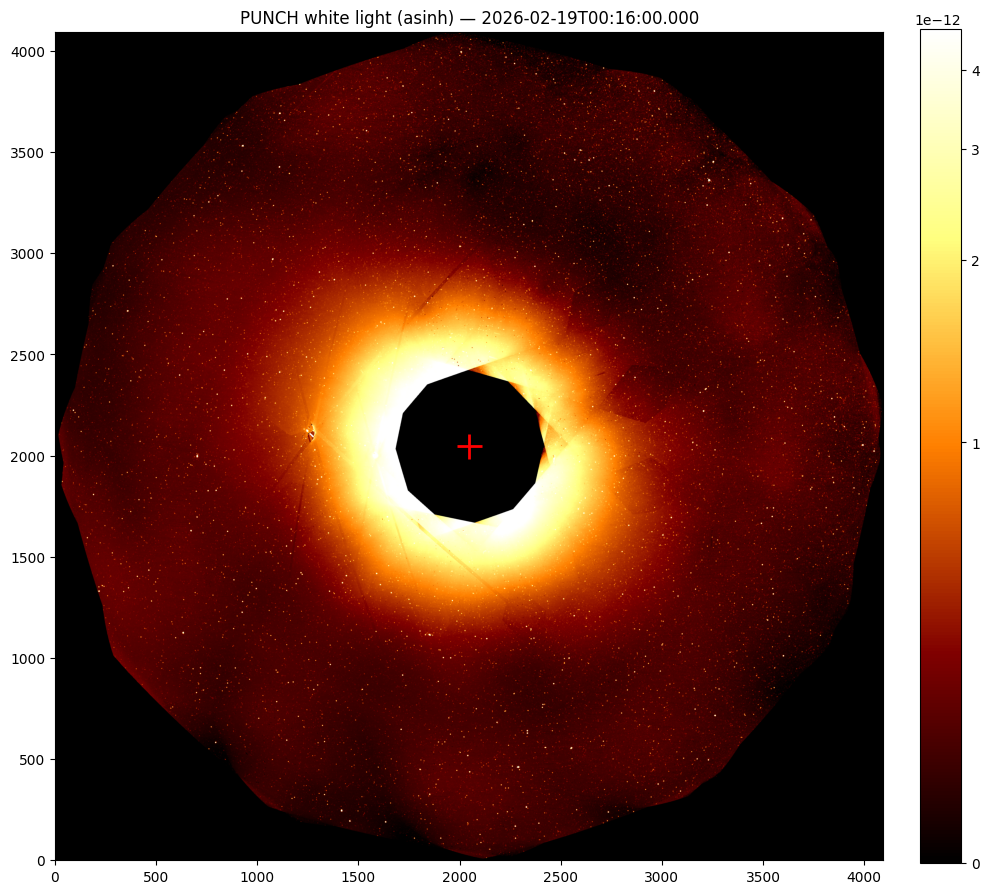

In [15]:
# Asinh stretch — try this if the log-stretch plot is too dark or too bright
norm_asinh = ImageNormalize(
    data,
    stretch=AsinhStretch(),
    vmin=0,
    vmax=np.nanpercentile(data, 99.5),
)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(data, origin="lower", cmap="afmhot", norm=norm_asinh)
ax.plot(sun_x, sun_y, "r+", markersize=18, markeredgewidth=2, label="Sun center")
ax.set_title(f"PUNCH white light (asinh) — {header['DATE-OBS']}")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [16]:
# Optional: save the log-stretch view next to the notebook
out_png = REPO_ROOT / "PUNCH_L3_CAM_view.png"

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(data, origin="lower", cmap="gray_r", norm=norm)
ax.plot(sun_x, sun_y, "r+", markersize=18, markeredgewidth=2)
ax.set_title(f"PUNCH white light — {header['DATE-OBS']}")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Saved: {out_png}")

Saved: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/PUNCH_L3_CAM_view.png
